In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mamdouhsamir/bird-neck-bones/bird-neck-bones.csv
/kaggle/input/datasets/mamdouhsamir/mammal-neck-bones/mammal-neck-bones.csv
/kaggle/input/datasets/mamdouhsamir/adult-human-skeleton/adult-human-skeleton.csv


In [2]:
#Skeletal Variation

import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/mamdouhsamir/adult-human-skeleton/adult-human-skeleton.csv')

df #display it


,name,region,subregion,side,fused_from
0,frontal,head,cranium,center,2
1,left parietal,head,cranium,left,1
2,right parietal,head,cranium,right,1
3,left temporal,head,cranium,left,1
4,right temporal,head,cranium,right,1
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


In [3]:
#Find the counts for each value in the 'region' column.
df['region'].value_counts()


region
hand     54
foot     52
torso    50
head     28
neck      8
leg       8
arm       6
Name: count, dtype: int64

In [4]:
#Sort by the 'fused_from' values.
#Use descending order.

df.sort_values(by='fused_from', ascending=False)



,name,region,subregion,side,fused_from
40,sternum,torso,chest,center,6
30,c2,neck,vertebra,center,5
82,sacrum,torso,pelvis,center,5
5,occipital,head,cranium,center,4
83,coccyx,torso,pelvis,center,4
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


In [5]:
#Select the 'fused_from' column.
#Add up all values in that column.

df['fused_from'].sum()



np.int64(305)

In [6]:
#Find all rows where the region is 'neck'.

df.query('region == "neck"')


,name,region,subregion,side,fused_from
28,hyoid,neck,throat,center,3
29,c1,neck,vertebra,center,3
30,c2,neck,vertebra,center,5
31,c3,neck,vertebra,center,3
32,c4,neck,vertebra,center,3
33,c5,neck,vertebra,center,3
34,c6,neck,vertebra,center,3
35,c7,neck,vertebra,center,3


In [7]:
#Mammal neck bones

#Load the mammal neck data.
#Display it.

mammals = pd.read_csv('/kaggle/input/datasets/mamdouhsamir/mammal-neck-bones/mammal-neck-bones.csv')
mammals #display it


,species,neck_vertebrae
0,cheetah,7
1,impala,7
2,giant panda,7
3,hartebeest,7
4,moose,7
...,...,...
297,alpaca,7
298,common wombat,7
299,red fox,7
300,fennec fox,7


In [8]:
#Show rows where the species is 'giraffe'.

mammals.query('species == "giraffe"')


,species,neck_vertebrae
108,giraffe,7


In [9]:
#Search for rows where the number of vertebrae does not equal 7.
mammals.query('neck_vertebrae != 7')


,species,neck_vertebrae
27,pale-throated sloth,9
28,brown-throated sloth,9
60,hoffmann's two-toed sloth,6
291,west indian manatee,6


In [10]:
#Bird neck bones

#Load the bird neck data.
#Display it.

birds = pd.read_csv('/kaggle/input/datasets/mamdouhsamir/bird-neck-bones/bird-neck-bones.csv')
birds #display it


,species,neck_vertebrae
0,cinereous vulture,13
1,guineafowl,14
2,red-legged partridge,14
3,blue-cheeked parrot,12
4,northern pintail,15
...,...,...
76,barn owl,12
77,eurasian hoopoe,13
78,murre,13
79,new zealand rockwren,13


<Axes: xlabel='neck_vertebrae'>

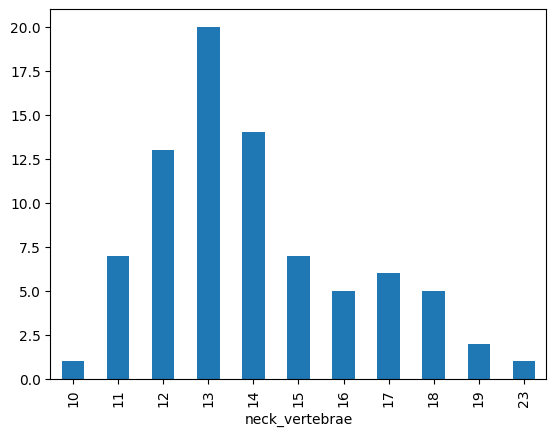

In [11]:
#Get the value counts for bird neck vertebrae.
#Sort by the index.
#Use series to make bar plot

bird_counts = birds['neck_vertebrae'].value_counts()
bird_counts = bird_counts.sort_index()
bird_counts.plot.bar()


In [12]:
#Find the rows with the maximum number of neck vertebrae.

birds.query('neck_vertebrae == neck_vertebrae.max()')


,species,neck_vertebrae
28,mute swan,23
